# Plot all templates under templates/

Loads every `.npy` file under `templates/` and plots its contents.
Use the settings cell to limit how many templates are shown per file.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# --- Settings ---
root = Path("./")
max_templates_per_file = 30
plot_psd_files = True  # set False to skip files with 'psd' in name


In [6]:
# --- Discover files ---
npy_files = sorted(root.rglob("*.npy"))
if not plot_psd_files:
    npy_files = [p for p in npy_files if 'psd' not in p.name.lower()]

print(f"Found {len(npy_files)} .npy files under {root}")
for p in npy_files:
    print(p)


Found 8 .npy files under .
signalformation_templates_V2-1.npy
vac_ch45_high_eng.npy
vac_ch45_low_eng.npy
vac_ch45_mid_eng.npy
vac_ch46plus0_mid_eng.npy
vac_ch46plus1_mid_eng.npy
vac_ch46plus_high_eng.npy
vac_ch46plus_low_eng.npy


In [7]:
def to_2d(arr):
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return arr.reshape(1, 1)
    if arr.ndim == 1:
        return arr[None, :]
    if arr.ndim == 2:
        return arr
    # flatten higher dims into (n_templates, n_samples)
    return arr.reshape(arr.shape[0], -1)

def plot_templates(path, max_rows=30):
    data = np.load(path)
    arr = to_2d(data)

    n_rows, n_cols = arr.shape
    if n_rows > max_rows:
        arr = arr[:max_rows]
        n_rows = max_rows

    plt.figure(figsize=(8, 3))
    for row in arr:
        plt.plot(row, alpha=0.7, linewidth=1)

    plt.title(f"{path} ({n_rows} templates, len={n_cols})")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.tight_layout()


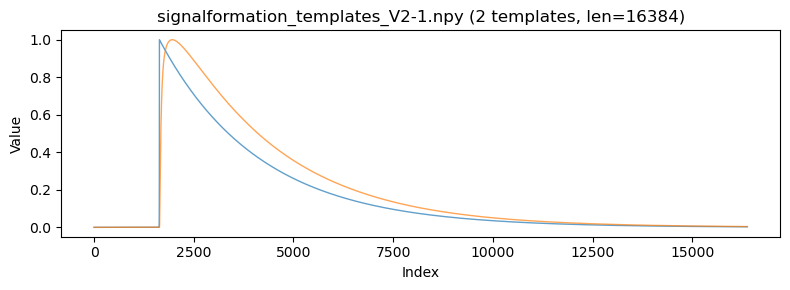

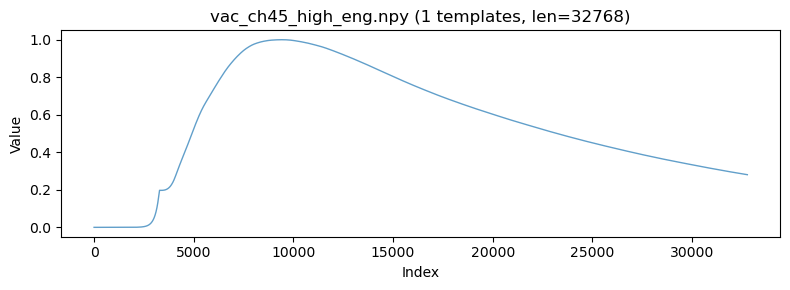

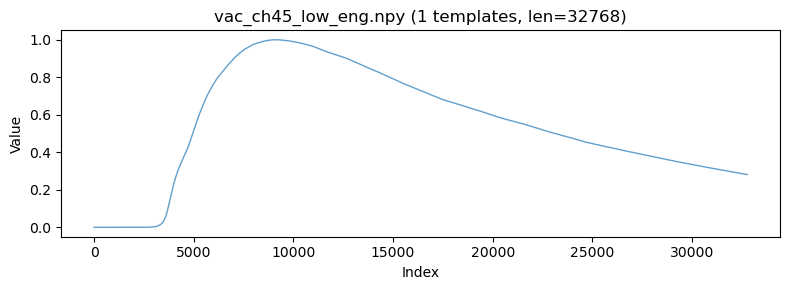

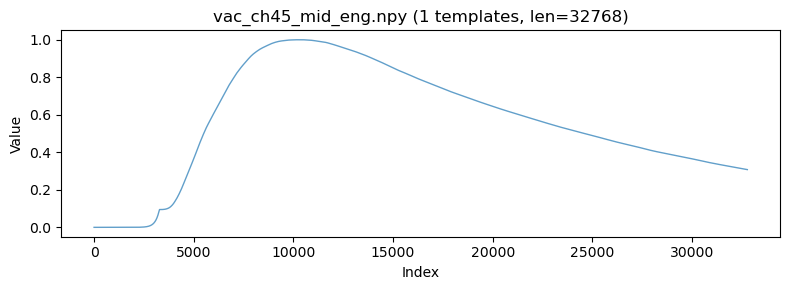

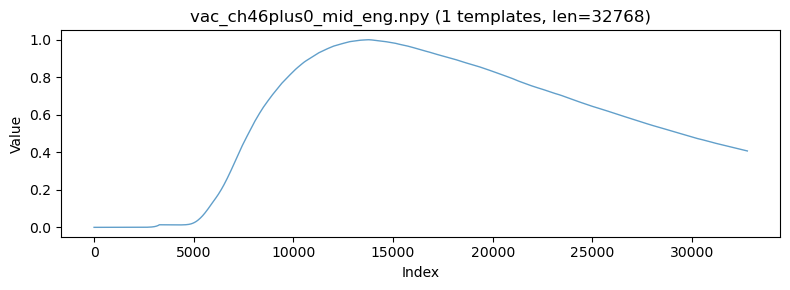

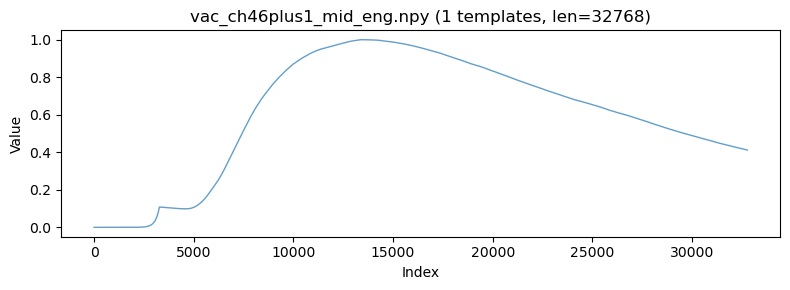

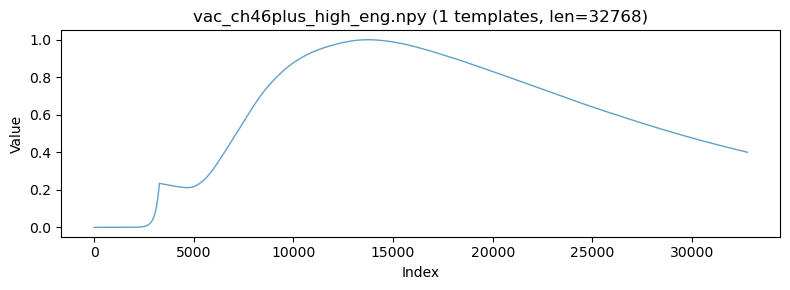

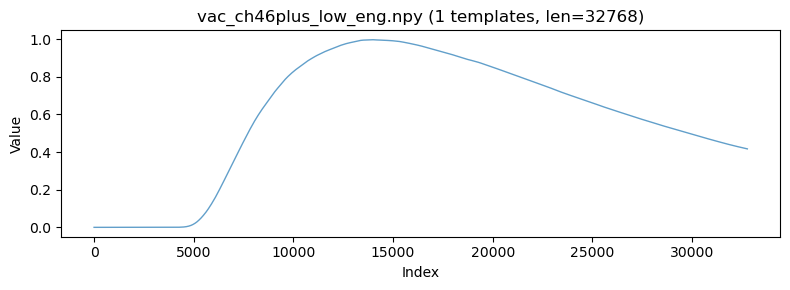

In [8]:
# --- Plot ---
for p in npy_files:
    plot_templates(p, max_rows=max_templates_per_file)

plt.show()
